# 이메일 스팸 분류 모델 3종 간단 비교

- 테스트 파일 480건 중 이메일 240건만 사용
- 비스팸 120건 / 스팸 120건
- 혼동행렬과 Classification Report만 출력

비교 모델:

1. TF-IDF + Logistic Regression
2. TF-IDF + LinearSVC
3. TF-IDF + MultinomialNB


In [13]:
# 1. 필요한 도구 불러오기

import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [18]:
# 2. 파일 경로 설정

BASE_DIR = Path('.')

TEST_PATH = (
    BASE_DIR
    / 'spam_test_master_email_sms_480.csv'
)

MODEL_PATHS = {
    'Logistic Regression': (
        BASE_DIR
        / 'email_spam_logistic_tfidf_v3.pkl'
    ),

    'LinearSVC': (
        BASE_DIR
        / 'email_spam_linearsvc_tfidf_v3.pkl'
    ),

    'MultinomialNB': (
        BASE_DIR
        / 'email_spam_multinomialnb_tfidf_v3.pkl'
    )
}


In [15]:
# 3. 테스트 데이터에서 이메일만 추출

test_data = pd.read_csv(
    TEST_PATH,
    encoding='utf-8-sig'
)

email_test = test_data.loc[
    test_data['channel']
    .astype(str)
    .str.strip()
    == '이메일'
].copy()

X_test = (
    email_test['text']
    .fillna('')
    .astype(str)
)

y_test = (
    email_test['expected_label']
    .astype(int)
)

print('이메일 테스트 데이터:', len(email_test))
print()
print('라벨 분포')
print(y_test.value_counts().sort_index())


이메일 테스트 데이터: 240

라벨 분포
expected_label
0    120
1    120
Name: count, dtype: int64


모델: Logistic Regression

혼동행렬
[[ 98  22]
 [ 17 103]]

Classification Report
              precision    recall  f1-score   support

         비스팸     0.8522    0.8167    0.8340       120
          스팸     0.8240    0.8583    0.8408       120

    accuracy                         0.8375       240
   macro avg     0.8381    0.8375    0.8374       240
weighted avg     0.8381    0.8375    0.8374       240



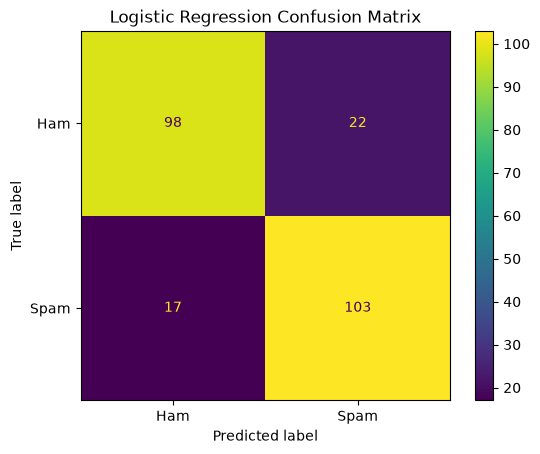

모델: LinearSVC

혼동행렬
[[ 58  62]
 [ 11 109]]

Classification Report
              precision    recall  f1-score   support

         비스팸     0.8406    0.4833    0.6138       120
          스팸     0.6374    0.9083    0.7491       120

    accuracy                         0.6958       240
   macro avg     0.7390    0.6958    0.6814       240
weighted avg     0.7390    0.6958    0.6814       240



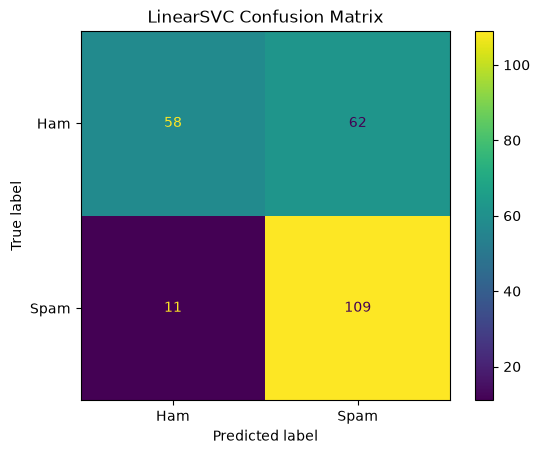

모델: MultinomialNB

혼동행렬
[[99 21]
 [23 97]]

Classification Report
              precision    recall  f1-score   support

         비스팸     0.8115    0.8250    0.8182       120
          스팸     0.8220    0.8083    0.8151       120

    accuracy                         0.8167       240
   macro avg     0.8168    0.8167    0.8167       240
weighted avg     0.8168    0.8167    0.8167       240



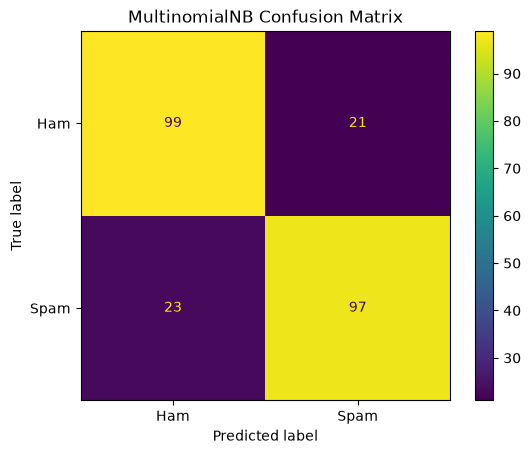

In [16]:
# 4. 세 모델의 혼동행렬과 Classification Report 출력

summary_rows = []

for model_name, model_path in MODEL_PATHS.items():

    with open(
        model_path,
        'rb'
    ) as file:
        model = pickle.load(file)

    y_pred = model.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=['비스팸', '스팸'],
        output_dict=True,
        zero_division=0
    )

    tn, fp, fn, tp = cm.ravel()

    summary_rows.append({
        '모델': model_name,
        'Accuracy': report_dict['accuracy'],
        'Precision': report_dict['스팸']['precision'],
        'Recall': report_dict['스팸']['recall'],
        'F1-score': report_dict['스팸']['f1-score'],
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    })

    print('=' * 75)
    print('모델:', model_name)
    print()
    print('혼동행렬')
    print(cm)
    print()
    print('Classification Report')
    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=['비스팸', '스팸'],
            digits=4,
            zero_division=0
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ham', 'Spam']
    ).plot(
        values_format='d'
    )

    plt.title(
        f'{model_name} Confusion Matrix'
    )
    plt.show()


In [17]:
# 5. 핵심 결과 비교표

comparison_result = pd.DataFrame(
    summary_rows
)

comparison_result


,모델,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,Logistic Regression,0.837500,0.824000,0.858333,0.840816,98,22,17,103
1,LinearSVC,0.695833,0.637427,0.908333,0.749141,58,62,11,109
2,MultinomialNB,0.816667,0.822034,0.808333,0.815126,99,21,23,97
